In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
file = '../data/outs/all_time.csv'

try:
    df = pd.read_csv(file, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo '{file}' não encontrado!")

Dados lidos com sucesso!


In [3]:
df.dtypes

nome      object
n          int64
m          int64
c          int64
fila      object
run        int64
l1         int64
l2         int64
llc        int64
cycles     int64
inst       int64
dtype: object

In [4]:
df.head()

,nome,n,m,c,fila,run,l1,l2,llc,cycles,inst
0,NY,264346,733846,36946,1LVBQ,78,0,0,0,0,0
1,NY,264346,733846,36946,1LVBQ,77,0,0,0,0,0
2,NY,264346,733846,36946,1LVBQ,77,0,0,0,0,0
3,NY,264346,733846,36946,1LVBQ,76,0,0,0,0,0
4,NY,264346,733846,36946,1LVBQ,76,0,0,0,0,0


## Tempo de execução por quantidade de vértices

In [5]:
df_run_n = (
    df.groupby(['nome', 'fila', 'n'])['run']
      .agg(['mean', 'std', 'var'])
      .reset_index()
)
df_run_n

,nome,fila,n,mean,std,var
0,BAY,1LVBQ,321270,95.1,1.100505,1.211111
1,CAL,1LVBQ,1890815,590.3,6.733828,45.344444
2,COL,1LVBQ,435666,144.3,0.823273,0.677778
3,CTR,1LVBQ,14081816,5216.7,59.981571,3597.788889
4,E,1LVBQ,3598623,1152.0,10.488088,110.000000
5,FLA,1LVBQ,1070376,327.8,0.788811,0.622222
6,LKS,1LVBQ,2758119,841.7,7.394442,54.677778
7,NE,1LVBQ,1524453,462.8,3.794733,14.400000
8,NW,1LVBQ,1207945,369.7,0.948683,0.900000
9,NY,1LVBQ,264346,76.4,0.699206,0.488889


In [6]:
df_run_n2 = df_run_n[df_run_n['fila'].isin(["BINH", "2LVBQDK"])]
df_run_n2

,nome,fila,n,mean,std,var


In [7]:
df_pivot = df_run_n2.pivot_table(
    index=['nome', 'n', 'm', 'c'],          # linhas (ex: BAY, CAL, COL...)
    columns=['fila'],        # vira colunas (BINH, 2LVBQDK)
    values=['mean', 'std'] # valores que você quer
)

df_pivot

KeyError: 'm'

In [ ]:
import math, numpy as np

df_pivot = df_pivot.reset_index()
df_pivot['sqrt_c'] = df_pivot['c'].apply(math.sqrt)
df_pivot['log_n'] = df_pivot['n'].apply(math.log2)

# Razões — "quantas vezes maior"
df_pivot['sqrt_vs_log_ratio'] = df_pivot['sqrt_c'] / df_pivot['log_n']
df_pivot

NameError: name 'df_pivot' is not defined

In [ ]:
latex = df_data.to_latex(
    index=False,
    column_format="|lrrrrrrr|",
    caption="Características dos grafos e tempo de execução do Dijkstra...",
    label="tab:res",
    float_format="%.1f"
)

print(latex)

\begin{table}
\caption{Características dos grafos e tempo de execução do Dijkstra...}
\label{tab:res}
\begin{tabular}{|lrrrrrrr|}
\toprule
nome & n & m & c & fila & sqrt_c & log_n & sqrt_vs_log_ratio \\
\midrule
BAY & 321270 & 800172 & 94305 & 2LVBQDK & 307.1 & 18.3 & 16.8 \\
CAL & 1890815 & 4657742 & 215354 & 2LVBQDK & 464.1 & 20.9 & 22.3 \\
COL & 435666 & 1057066 & 137384 & 2LVBQDK & 370.7 & 18.7 & 19.8 \\
CTR & 14081816 & 34292496 & 214013 & 2LVBQDK & 462.6 & 23.7 & 19.5 \\
E & 3598623 & 8778114 & 200760 & 2LVBQDK & 448.1 & 21.8 & 20.6 \\
FLA & 1070376 & 2712798 & 214013 & 2LVBQDK & 462.6 & 20.0 & 23.1 \\
LKS & 2758119 & 6885658 & 138911 & 2LVBQDK & 372.7 & 21.4 & 17.4 \\
NE & 1524453 & 3897636 & 63247 & 2LVBQDK & 251.5 & 20.5 & 12.2 \\
NW & 1207945 & 2840208 & 128569 & 2LVBQDK & 358.6 & 20.2 & 17.7 \\
NY & 264346 & 733846 & 36946 & 2LVBQDK & 192.2 & 18.0 & 10.7 \\
USA & 23947347 & 58333344 & 368855 & 2LVBQDK & 607.3 & 24.5 & 24.8 \\
W & 6262104 & 15248146 & 368855 & 2LVBQDK & 607.3

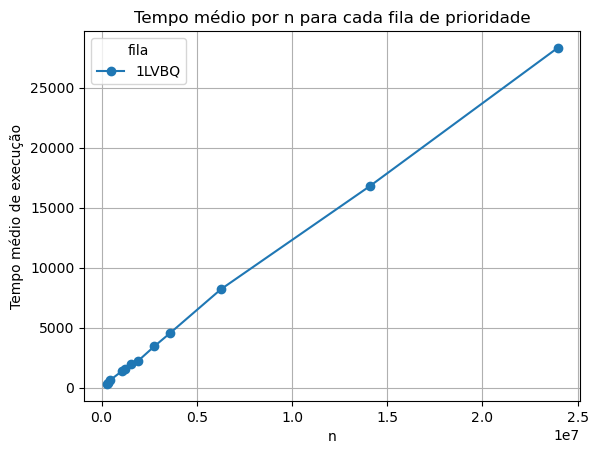

In [ ]:
pivot = df.groupby(['n','fila'])['run'].mean().unstack()

pivot.plot(marker='o')
plt.xlabel('n')
plt.ylabel('Tempo médio de execução')
plt.title('Tempo médio por n para cada fila de prioridade')
plt.grid(True)
plt.savefig('run_n.png', dpi=300, bbox_inches='tight')
plt.show()


## Correlação entre métricas e tempo de execução

In [ ]:
df['l1_mr'] = df['l1'] / df['cycles']
df['l2_mr'] = df['l2'] / df['cycles']
df['llc_mr'] = df['llc'] / df['cycles']

In [ ]:
df_run_miss = (
    df.groupby(['nome','fila'])[['run','l1','l2','llc','cycles', 'inst', 'l1_mr', 'l2_mr', 'llc_mr']]
      .mean()
      .reset_index()
)

In [ ]:
df_run_miss

,nome,fila,run,l1,l2,llc,cycles,inst,l1_mr,l2_mr,llc_mr
0,BAY,1LVBQ,381.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
1,CAL,1LVBQ,2189.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
2,COL,1LVBQ,605.5,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
3,CTR,1LVBQ,16794.1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
4,E,1LVBQ,4547.8,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
5,FLA,1LVBQ,1378.4,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
6,LKS,1LVBQ,3426.9,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
7,NE,1LVBQ,1927.1,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
8,NW,1LVBQ,1565.3,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
9,NY,1LVBQ,301.8,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN
